<h1> <center> DEMs, Rasters, and related tools </center></h1>

## What are the primary formats we use for DEMs?

On VICTOR, we use two main types of file for topographical data.

#### <center> ASCII | TIFF/GeoTIFF </center>

The former is readable by all of us, and has no additional/hidden information. If a need for multiple bands or a specific projection are required, additional files must be proved.<br/>The latter is binary encoded, so we cannot read it like normal text, and has additional parameters/properties set in the file.

In [6]:
import rasterio as rio
import rioxarray as rxr
import xarray as xr
import sys
import pyproj
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
sys.path.insert(0, "/home/jovyan/shared/Libraries")
import victor
import urllib.request
import utm
import openpyxl

In [7]:
#Choose a volcano and DEM options

volcano = victor.search_volcano('Pinatubo') # Get volcano information from the GVP database

center_lat = volcano[1][0]  # Get volcano latitude
center_lon = volcano[2][0]  # Get volcano longitude

# Set the extent of the region of interest, in meters in each direction from the summit
eastwest_extent = 11000
northsouth_extent = 8000

# Set bounding box in lat/lon
utms = utm.from_latlon(center_lat, center_lon)
[north_lat, east_lon] = utm.to_latlon(utms[0]+eastwest_extent, utms[1]+northsouth_extent, utms[2], utms[3])
[south_lat, west_lon] = utm.to_latlon(utms[0]-eastwest_extent, utms[1]-northsouth_extent, utms[2], utms[3])

# Select a DEM format: Input "ascii" for ASCII format (.asc) and "tiff" for geotiff format
outputFormat = "tiff"

# Enter the name of the output file (without extension)
name = "Pinatubu"

dataset = "SRTMGL1"

print(center_lat, center_lon) 

15.13 120.35


### First, let's pick a volcano, and download a DEM for it.

In [8]:
lon = center_lon

lat = center_lat

### We need to determine the UTM coordinates of the volcano. Let's change the projection/CRS.

In [9]:
(utm_east, utm_north, zone, _) = utm.from_latlon(lat, lon)
print(utm_east,utm_north, zone)

4951575.000592462 17880648.68586562


## Now, we can use the VICTOR library to download a DEM.

### For the sake of this problem, set bounds 2 km out from the crater on each side. Use the Copericus dataset (code COP30) for the download.

In [10]:
victor.download_dem(lat+.05,lat-.05,lon+.05,lon-.05,"ascii","COP30")

DEM downloaded as DEM_15N_15S_120W_120E_COP30_03022025.asc


'DEM_15N_15S_120W_120E_COP30_03022025.asc'

In [5]:
victor.download_dem_utm(utm_north+6000,utm_north-5000,utm_east+5000,utm_east-5000, hemisphere='S',utm_zone=51, dataset="COP30", outputFormat="tiff")

DEM downloaded as DEM_63N_63S_-22W_-22E_COP30_03022025.geotiff


### Recently, we've also implemented a higher resolution US focused function using USGS data.

In [ ]:
victor.download_dem_usgs(40.288, 40.234, -105.583, -105.673, "ascii", '10m')

The files download in latitude/longitude, so lets convert to UTM.

In [11]:
filename = "DEM_15N_15S_120W_120E_COP30_03022025.asc"
victor.dem_to_utm(infile=filename, outfile="opentopo.asc")

## Now, we can take a brief look behind the scenes.
https://opentopography.org/

https://portal.opentopography.org/apidocs/#/

## Next, we can plot the DEM we just downloaded.

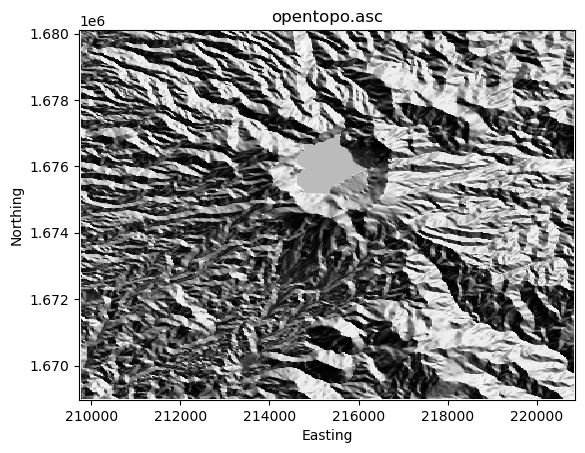

In [14]:
victor.plot_dem("opentopo.asc", markercoords = np.array([utm_east,utm_north]))

### Now, thre are a few libraries I would like to focus on.

https://rasterio.readthedocs.io/en/stable/

https://docs.xarray.dev/en/stable/#

https://corteva.github.io/rioxarray/stable/

In [15]:
demarray = rxr.open_rasterio("opentopo.asc")
demarray

<xarray.DataArray (band: 1, y: 360, x: 360)> Size: 518kB
[129600 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 3kB 2.097e+05 2.098e+05 ... 2.208e+05 2.208e+05
  * y            (y) float64 3kB 1.68e+06 1.68e+06 ... 1.669e+06 1.669e+06
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    0.0
    scale_factor:  1.0
    add_offset:    0.0